In [77]:
import os
from spectral.io import envi
import numpy as np
import ray
import logging
import json
from glob import glob
import matplotlib.pyplot as plt
import geopandas as gpd
import rasterio
from rasterio.transform import array_bounds
from rasterio.plot import show
from rasterio.plot import plotting_extent
import itertools
import random

import sys
sys.path.append('/store/carroll/repos/neon-isofit/')
from utilities import viz_rfl_subset

# %matplotlib widget

In [5]:
data = '/store/carroll/col/data/2018/'
home = os.path.join(data, 'test_6c')
out_figs = '/store/carroll/col/figs/'

flight = 'NIS01_20180612_155442'
rs = ['336000_4307000', '336000_4310000']

fp = glob(os.path.join(home, '*', 'output', '*_rfl.hdr'))[0]
wl = np.array([float(x) for x in envi.read_envi_header(fp)['wavelength']])
def closest_wl(mv):
    return np.argmin(np.abs(wl-mv))
wl_nan = wl.copy()
wl_nan[closest_wl(1360):closest_wl(1410)] = np.nan
wl_nan[closest_wl(1800):closest_wl(1970)] = np.nan

In [7]:
r

'336000_4307000'

In [9]:
os.path.join(home+f'*{r}')

'/store/carroll/col/data/2018/test_6c*336000_4307000'

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [0.0..3.3333333].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [0.0..3.3333333].


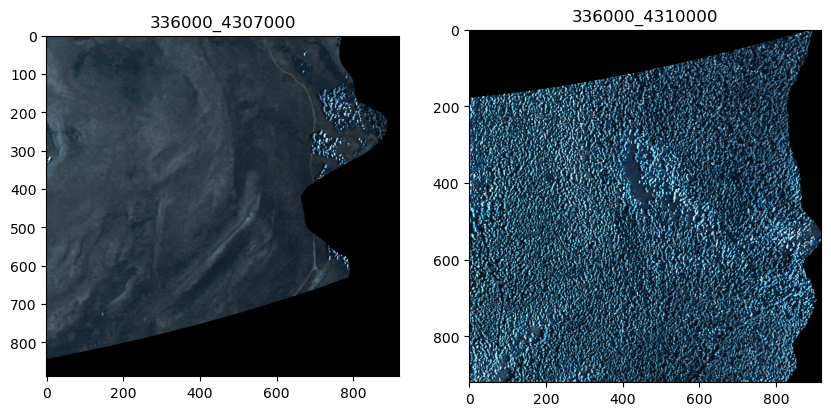

In [18]:
# rfl rgb for both regions

fig, axs = plt.subplots(ncols=2, figsize=(10,5))

for i in [0,1]:
    r = rs[i]
    working_dir = glob(os.path.join(home,f'*{r}'))[0]
    fp = glob(os.path.join(working_dir, 'output', f'*_rfl.hdr'))[0]
    rgb = envi.open(fp).open_memmap()[:,:,np.array([60,40,30])].copy()
    axs[i].imshow(rgb / (np.nanmax(rgb, axis=(0, 1))*0.3))
    axs[i].set_title(r)

plt.show()

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [0.011632947..3.3333333].


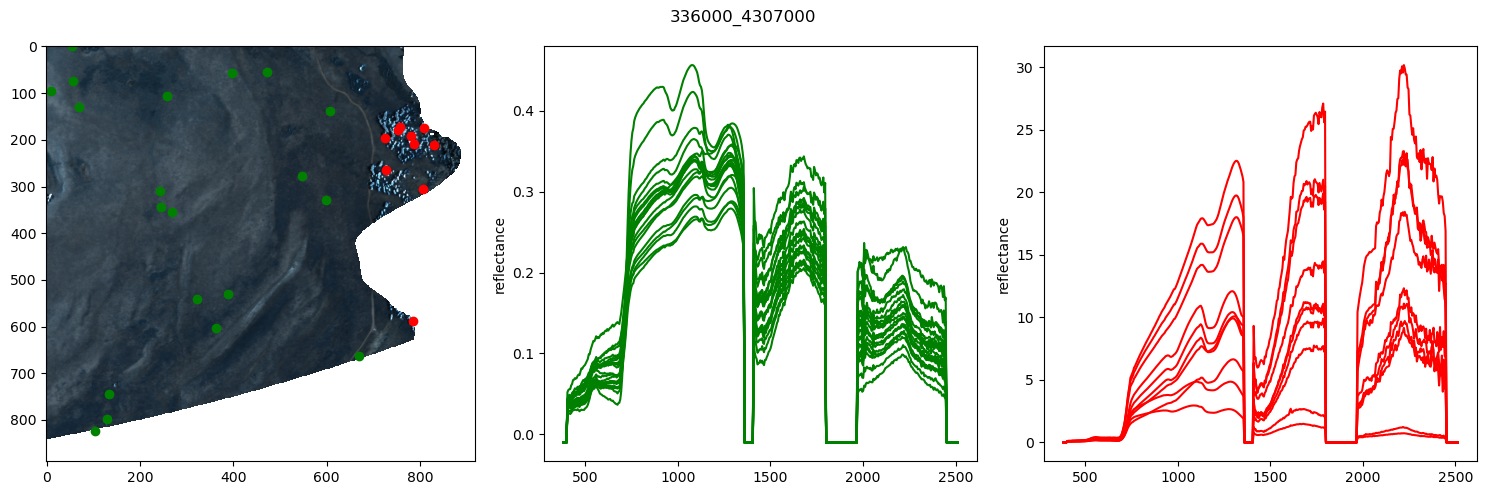

In [109]:
# plot some spectra

r = rs[0]
working_dir = glob(os.path.join(home,f'*{r}'))[0]
fp = glob(os.path.join(working_dir, 'output', f'*_rfl.hdr'))[0]

rfl = envi.open(fp).open_memmap()[:].copy()
rgb = envi.open(fp).open_memmap()[:,:,np.array([60,40,30])].copy()
rgb[rgb==0] = np.nan

# choose rows, cols
# rows = list(range(50, 700, 100))
# cols = list(range(50, 700, 100))
# good_pts = list(itertools.product(rows,cols))
tmp = (rfl[...,150] < 1) & (rfl[...,150] > 0)
good_pts = np.where(tmp)
good_pts = list(zip(good_pts[0], good_pts[1]))
good_pts = random.sample(good_pts, 20)

tmp = rfl[...,150]>2
bad_pts = np.where(tmp)
bad_pts = list(zip(bad_pts[0], bad_pts[1]))
bad_pts = random.sample(bad_pts, 10)

# viz
fig, axs = plt.subplots(ncols=3, figsize=(15,5))

axs[0].imshow(rgb / (np.nanmax(rgb, axis=(0, 1))*0.3))

for i in range(len(good_pts)):
    row = good_pts[i][0]
    col = good_pts[i][1]
    axs[1].plot(wl, rfl[row, col, :], label=f'row {row} col {col}', color='green')
    axs[0].scatter(col, row, label=f'row {row} col {col}', color='green')
    axs[1].set_ylabel('reflectance')

for i in range(len(bad_pts)):
    row = bad_pts[i][0]
    col = bad_pts[i][1]
    axs[2].plot(wl, rfl[row, col, :], label=f'row {row} col {col}', color='red')
    axs[0].scatter(col, row, label=f'row {row} col {col}', color='red')
    axs[2].set_ylabel('reflectance')


fig.suptitle(r)
plt.tight_layout() 
plt.show()


Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [0.0055025653..3.3333333].


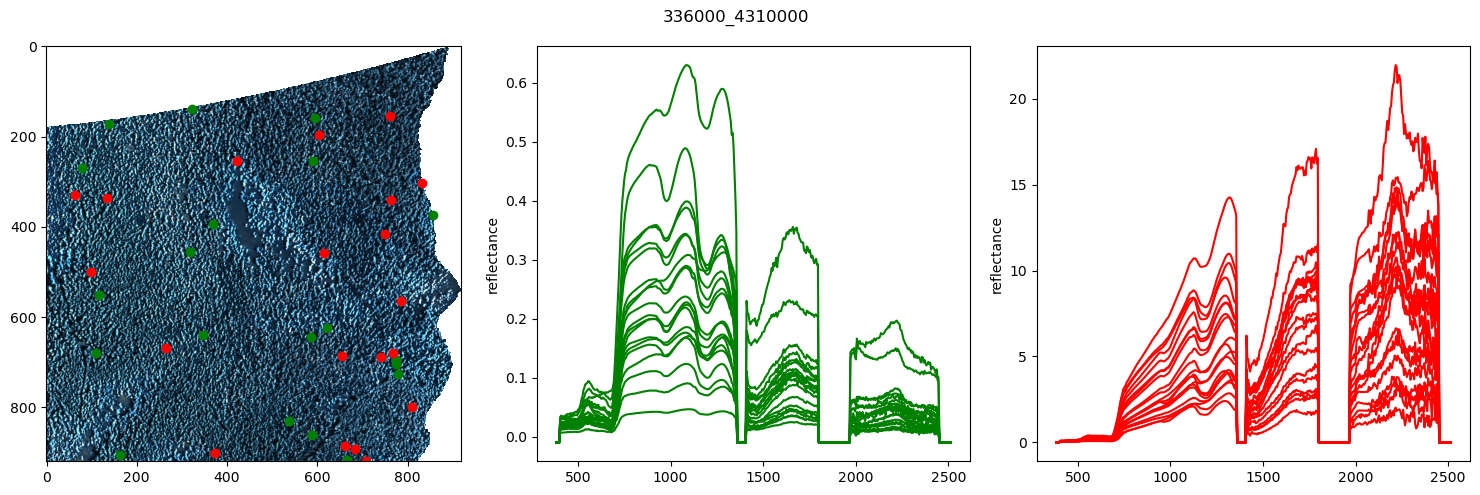

In [110]:
# plot some spectra

r = rs[1]
working_dir = glob(os.path.join(home,f'*{r}'))[0]
fp = glob(os.path.join(working_dir, 'output', f'*_rfl.hdr'))[0]

rfl = envi.open(fp).open_memmap()[:].copy()
rgb = envi.open(fp).open_memmap()[:,:,np.array([60,40,30])].copy()
rgb[rgb==0] = np.nan

# choose rows, cols
tmp = (rfl[...,150] < 1) & (rfl[...,150] > 0)
good_pts = np.where(tmp)
good_pts = list(zip(good_pts[0], good_pts[1]))
good_pts = random.sample(good_pts, 20)

tmp = rfl[...,150]>2
bad_pts = np.where(tmp)
bad_pts = list(zip(bad_pts[0], bad_pts[1]))
bad_pts = random.sample(bad_pts, 20)

# viz
fig, axs = plt.subplots(ncols=3, figsize=(15,5))

axs[0].imshow(rgb / (np.nanmax(rgb, axis=(0, 1))*0.3))

for i in range(len(good_pts)):
    row = good_pts[i][0]
    col = good_pts[i][1]
    axs[1].plot(wl, rfl[row, col, :], label=f'row {row} col {col}', color='green')
    axs[0].scatter(col, row, label=f'row {row} col {col}', color='green')
    axs[1].set_ylabel('reflectance')

for i in range(len(bad_pts)):
    row = bad_pts[i][0]
    col = bad_pts[i][1]
    axs[2].plot(wl, rfl[row, col, :], label=f'row {row} col {col}', color='red')
    axs[0].scatter(col, row, label=f'row {row} col {col}', color='red')
    axs[2].set_ylabel('reflectance')


fig.suptitle(r)
plt.tight_layout() 
plt.show()
